# MKP-Transformer pretrained reproduction

This notebook runs the unified DeepACO reproduction entry point for this problem. It writes logs, raw JSON, Markdown tables, and PNG figures to the repository-level output folders.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'pretrained').exists() else cwd.parent
sys.path.insert(0, str(ROOT))

from scripts.reproduce_problem import run_problem

PROBLEM = 'mkp_transformer'
DEVICE = 'auto'          # 'auto', 'cpu', 'cuda', or 'cuda:0'
SEED = 12345
LIMIT_INSTANCES = None   # set to a small integer for a quick smoke test
SIZES = None             # e.g. [20] or None for all configured scales
T_ACO = None             # e.g. [1, 10] or None for paper-style checkpoints
METHODS = None           # e.g. ['deepaco'] or ['deepaco', 'aco']
INCLUDE_BASELINE = True


e:\DeepAoc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
raw = run_problem(
    PROBLEM,
    sizes=SIZES,
    t_aco=T_ACO,
    methods=METHODS,
    limit_instances=LIMIT_INSTANCES,
    device=DEVICE,
    seed=SEED,
    include_baseline=INCLUDE_BASELINE,
)
raw['outputs']


[2026-05-11T09:46:09] Starting MKP-Transformer reproduction
[2026-05-11T09:46:09] sizes=[300, 500], t_aco=[1, 5, 10, 20, 50], methods=['deepaco', 'aco'], device=cpu
[2026-05-11T09:46:09] MKP-Transformer300: 100/100 instances
[2026-05-11T10:07:28] Finished MKP-Transformer 300 DeepACO-Transformer in 1278.61s
[2026-05-11T10:26:02] Finished MKP-Transformer 300 ACO in 1114.54s
[2026-05-11T10:26:02] Generating missing MKP-Transformer dataset: data/mkp_transformer/testDataset-500.pt
[2026-05-11T10:26:03] MKP-Transformer500: 100/100 instances
[2026-05-11T10:59:24] Finished MKP-Transformer 500 DeepACO-Transformer in 2001.11s
[2026-05-11T11:28:31] Finished MKP-Transformer 500 ACO in 1747.18s
[2026-05-11T11:28:33] Wrote raw results: results/raw/mkp_transformer_results.json
[2026-05-11T11:28:33] Wrote table: results/tables/mkp_transformer_table.md
[2026-05-11T11:28:33] Wrote figure: results/figures/mkp_transformer_comparison.png


{'raw': 'results/raw/mkp_transformer_results.json',
 'table': 'results/tables/mkp_transformer_table.md',
 'figure': 'results/figures/mkp_transformer_comparison.png',
 'log': 'logs/mkp_transformer.log'}

# MKP-Transformer Reproduction Table

- Metric: average objective (higher is better)
- Instances per completed row: see `instances` column
- Device: cpu

| scale | method | status | instances | duration_s | T=1 | T=5 | T=10 | T=20 | T=50 | gap_vs_aco_last |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 300 | DeepACO-Transformer | ok | 100 | 1278.61 | 62.8857 | 63.1614 | 63.2035 | 63.2644 | 63.3233 | +2.40% |
| 300 | ACO | ok | 100 | 1114.54 | 46.6903 | 55.493 | 58.2231 | 60.2641 | 61.8418 |  |
| 500 | DeepACO-Transformer | ok | 100 | 2001.11 | 101.667 | 102.494 | 102.763 | 102.968 | 103.297 | +2.27% |
| 500 | ACO | ok | 100 | 1747.18 | 75.3242 | 89.3762 | 94.0226 | 97.944 | 101.005 |  |


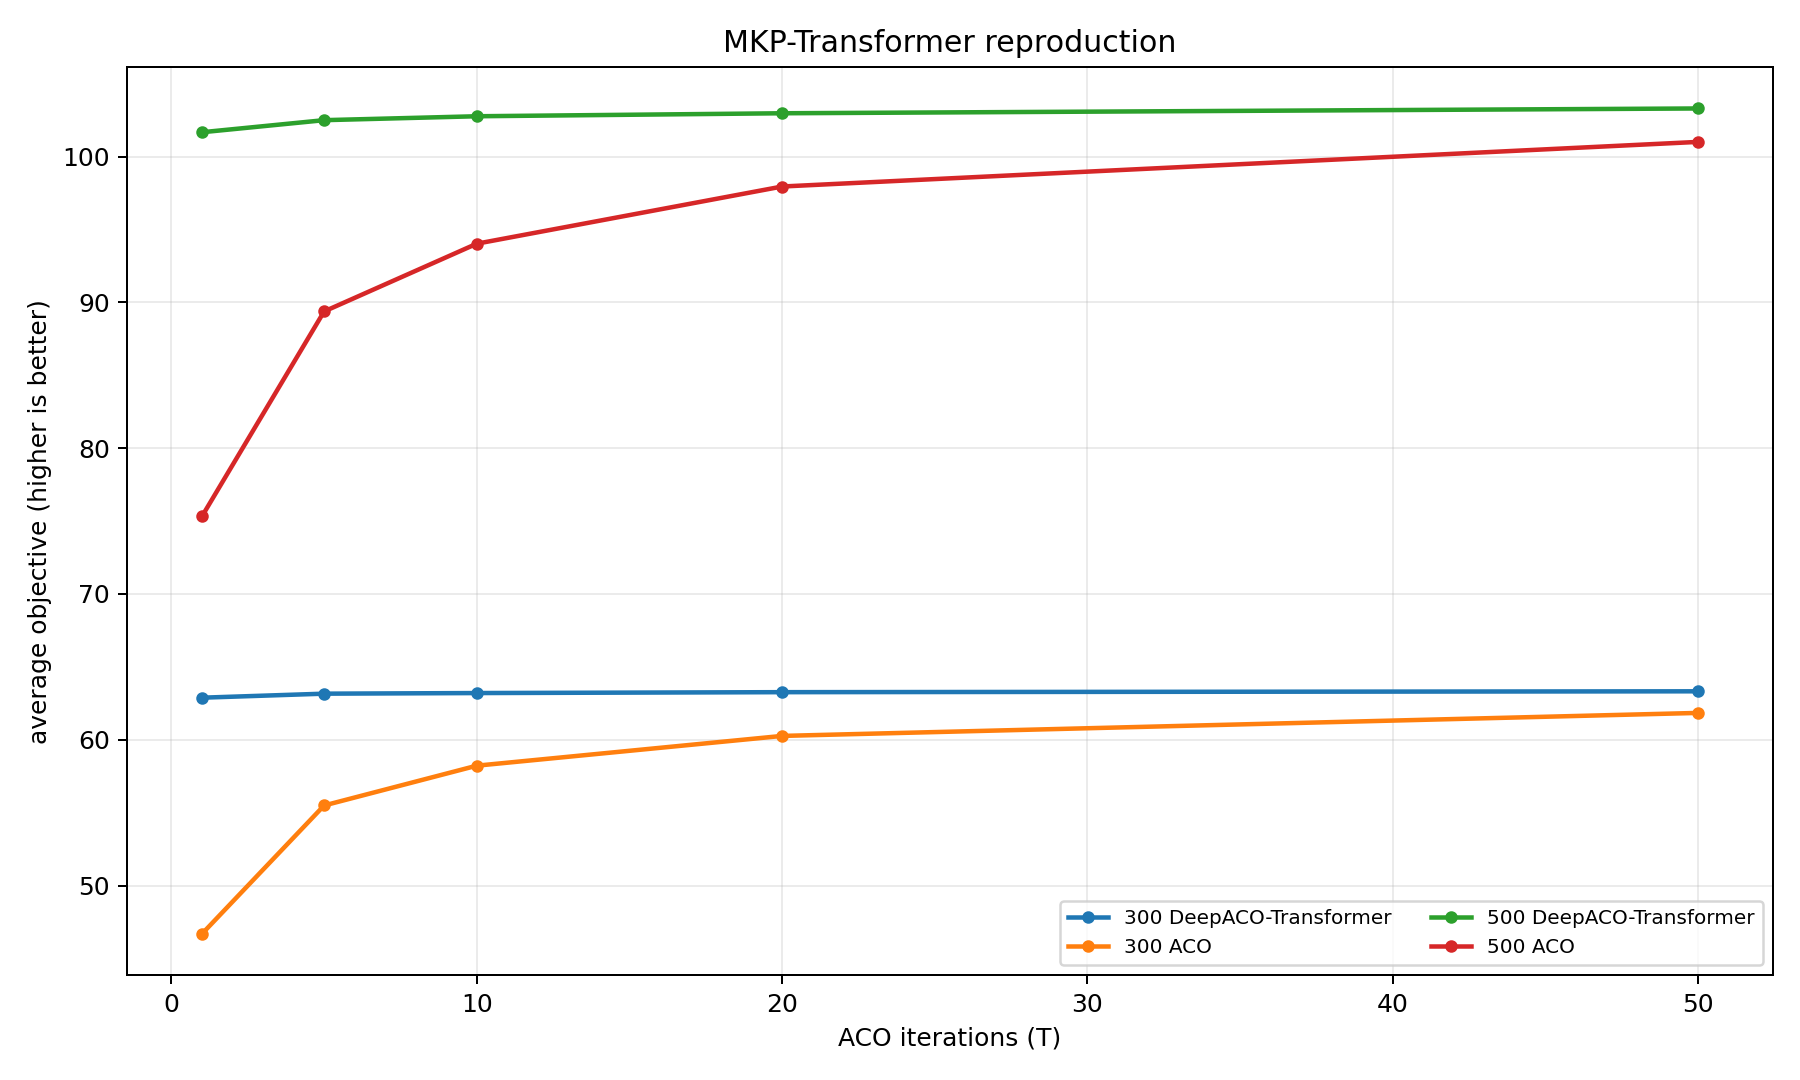

In [3]:
from IPython.display import Image, Markdown, display

outputs = raw['outputs'] if 'raw' in globals() else {
    'table': f'results/tables/{PROBLEM}_table.md',
    'figure': f'results/figures/{PROBLEM}_comparison.png',
}

table_path = ROOT / outputs['table']
figure_path = ROOT / outputs['figure']

display(Markdown(table_path.read_text(encoding='utf-8')))
display(Image(filename=str(figure_path)))
